# 🧠 EmoNeXt — From-Scratch Facial Expression Recognition

## Novel Architecture: EmoNeXt (Emotion Recognition NeXt)

**Trained 100% from scratch — zero pretrained weights.**

### Architecture Highlights
| Component | Description |
|-----------|-------------|
| **Stem** | Overlapping conv stem (stride-2 convolutions) |
| **Backbone** | 4-stage cascade of **EmoNeXt Blocks** (inverted residual + SE attention) |
| **MFSA** | **Multi-Frequency Spatial Attention** — captures expression cues at different spatial frequencies via multi-scale dilated convolutions |
| **FRAP** | **Facial Region-Aware Pooling** — 4-quadrant + global pooling with learned region gates |
| **Loss** | **Adaptive Focal Loss** — per-class learnable focusing parameter γ |
| **Training** | Warmup-cosine schedule, AMP, DropPath, Mixup, strong augmentation |

### Dataset
- **AffectNet 8-class**: Neutral, Happy, Sad, Surprise, Fear, Disgust, Anger, Contempt
- Stratified 70/15/15 train/val/test split
- Weighted sampling for class imbalance

### Hardware Target
- NVIDIA GTX 1650 (4GB VRAM)
- Mixed precision (AMP) for speed & memory efficiency

In [26]:
# ============================================================
# CELL 1: Environment Setup & Imports
# ============================================================
import os, sys, math, random, time, copy, json, gc, itertools, warnings
from pathlib import Path
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)

from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    vram = props.total_memory / 1e9
    print(f'GPU    : {props.name} ({vram:.1f} GB)')
print(f'PyTorch: {torch.__version__}')
print(f'Albumentations: {A.__version__}')
print(f'OpenCV : {cv2.__version__}')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650 (3.9 GB)
PyTorch: 2.10.0+cu128
Albumentations: 2.0.8
OpenCV : 4.13.0


---
## ⚙️ Configuration

In [27]:
# ============================================================
# CELL 2: Configuration — All hyperparameters
# ============================================================
DATASET_ROOT  = Path('./Dataset_Combined')
OUTPUT_ROOT   = Path('./emonext_outputs')
MODEL_DIR     = OUTPUT_ROOT / 'saved_models'
PLOT_DIR      = OUTPUT_ROOT / 'plots'
LOG_DIR       = OUTPUT_ROOT / 'logs'
EMBED_DIR     = OUTPUT_ROOT / 'embeddings'

for d in [MODEL_DIR, PLOT_DIR, LOG_DIR, EMBED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Neutral', 'Happy', 'Sad', 'Surprise',
               'Fear', 'Disgust', 'Anger', 'Contempt']
NUM_CLASSES = 8

# Folder name → class index mapping (handles inconsistent casing)
FOLDER_MAP = {
    'neutral': 0, 'happy': 1, 'sad': 2, 'surprise': 3,
    'fear': 4, 'disgust': 5, 'anger': 6, 'contempt': 7,
}

CFG = {
    'IMG_SIZE'       : 224,
    'BATCH_SIZE'     : 24,
    'GRAD_ACCUM'     : 4,           # effective batch = 96
    'USE_AMP'        : True,
    'NUM_WORKERS'    : 2,
    'PIN_MEMORY'     : True,

    # EmoNeXt architecture
    'CHANNELS'       : [64, 128, 256, 384],    # per stage
    'DEPTHS'         : [2, 3, 4, 2],           # blocks per stage
    'EXPAND_RATIO'   : 3,
    'SE_RATIO'       : 4,
    'DROPOUT'        : 0.2,
    'DROP_PATH'      : 0.15,
    'USE_MFSA'       : True,       # Multi-Frequency Spatial Attention

    # Training from scratch
    'EPOCHS'         : 100,
    'WARMUP_EPOCHS'  : 5,
    'LR'             : 1e-3,       # higher for from-scratch
    'LR_MIN'         : 1e-6,
    'WEIGHT_DECAY'   : 1e-4,

    # Loss
    'LABEL_SMOOTHING': 0.1,
    'FOCAL_GAMMA'    : 2.0,
    'FOCAL_WEIGHT'   : 0.5,        # blend: (1-w)*CE + w*Focal

    # Augmentation
    'ROTATION_LIMIT' : 25,
    'MIXUP_ALPHA'    : 0.3,
    'CUTMIX_ALPHA'   : 1.0,
    'MIXUP_PROB'     : 0.4,

    # Misc
    'EARLY_STOP'     : 20,
    'SEED'           : SEED,
}

EFF_BATCH = CFG['BATCH_SIZE'] * CFG['GRAD_ACCUM']
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('=' * 60)
print('⚙️  EmoNeXt FROM-SCRATCH Configuration')
print('=' * 60)
for k, v in CFG.items():
    print(f'  {k:20s}: {v}')
print(f'  {"EFF_BATCH":20s}: {EFF_BATCH}')
print('=' * 60)

with open(LOG_DIR / 'config.json', 'w') as f:
    json.dump({k: str(v) for k, v in CFG.items()}, f, indent=2)

⚙️  EmoNeXt FROM-SCRATCH Configuration
  IMG_SIZE            : 224
  BATCH_SIZE          : 24
  GRAD_ACCUM          : 4
  USE_AMP             : True
  NUM_WORKERS         : 2
  PIN_MEMORY          : True
  CHANNELS            : [64, 128, 256, 384]
  DEPTHS              : [2, 3, 4, 2]
  EXPAND_RATIO        : 3
  SE_RATIO            : 4
  DROPOUT             : 0.2
  DROP_PATH           : 0.15
  USE_MFSA            : True
  EPOCHS              : 100
  WARMUP_EPOCHS       : 5
  LR                  : 0.001
  LR_MIN              : 1e-06
  WEIGHT_DECAY        : 0.0001
  LABEL_SMOOTHING     : 0.1
  FOCAL_GAMMA         : 2.0
  FOCAL_WEIGHT        : 0.5
  ROTATION_LIMIT      : 25
  MIXUP_ALPHA         : 0.3
  CUTMIX_ALPHA        : 1.0
  MIXUP_PROB          : 0.4
  EARLY_STOP          : 20
  SEED                : 42
  EFF_BATCH           : 96


---
## 📁 Dataset Discovery & Validation

✅ Found 29,042 valid images (0 corrupt removed)

Class distribution:
  Neutral   :  5126  ███████████████████████████████████████████████████
  Happy     :  5044  ██████████████████████████████████████████████████
  Sad       :  3091  ██████████████████████████████
  Surprise  :  4039  ████████████████████████████████████████
  Fear      :  3176  ███████████████████████████████
  Disgust   :  2477  ████████████████████████
  Anger     :  3218  ████████████████████████████████
  Contempt  :  2871  ████████████████████████████

  Max/Min ratio: 2.07x imbalance


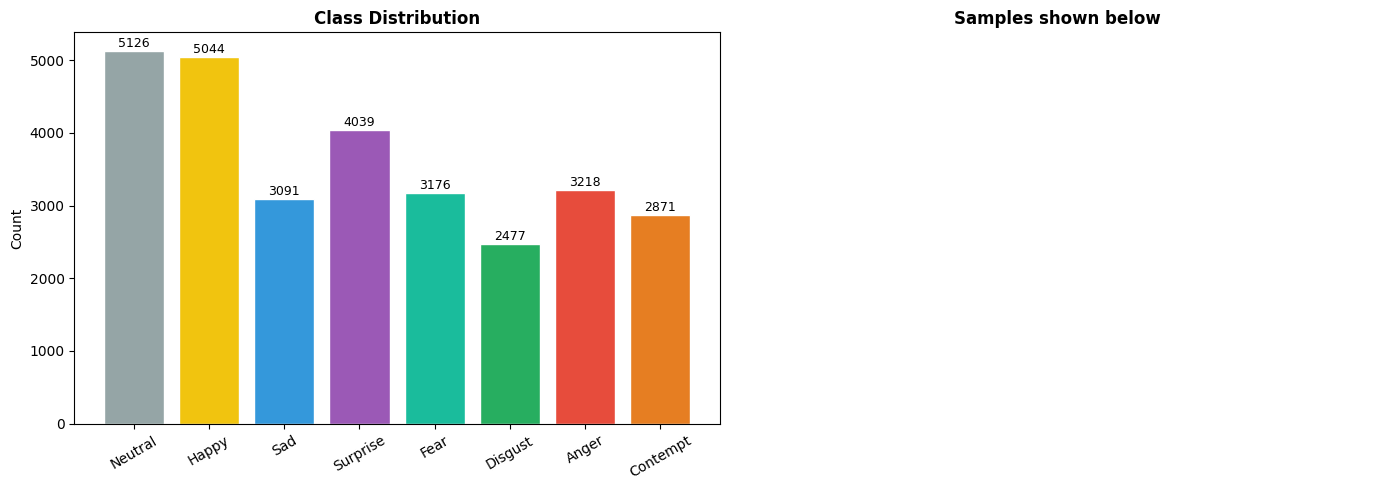

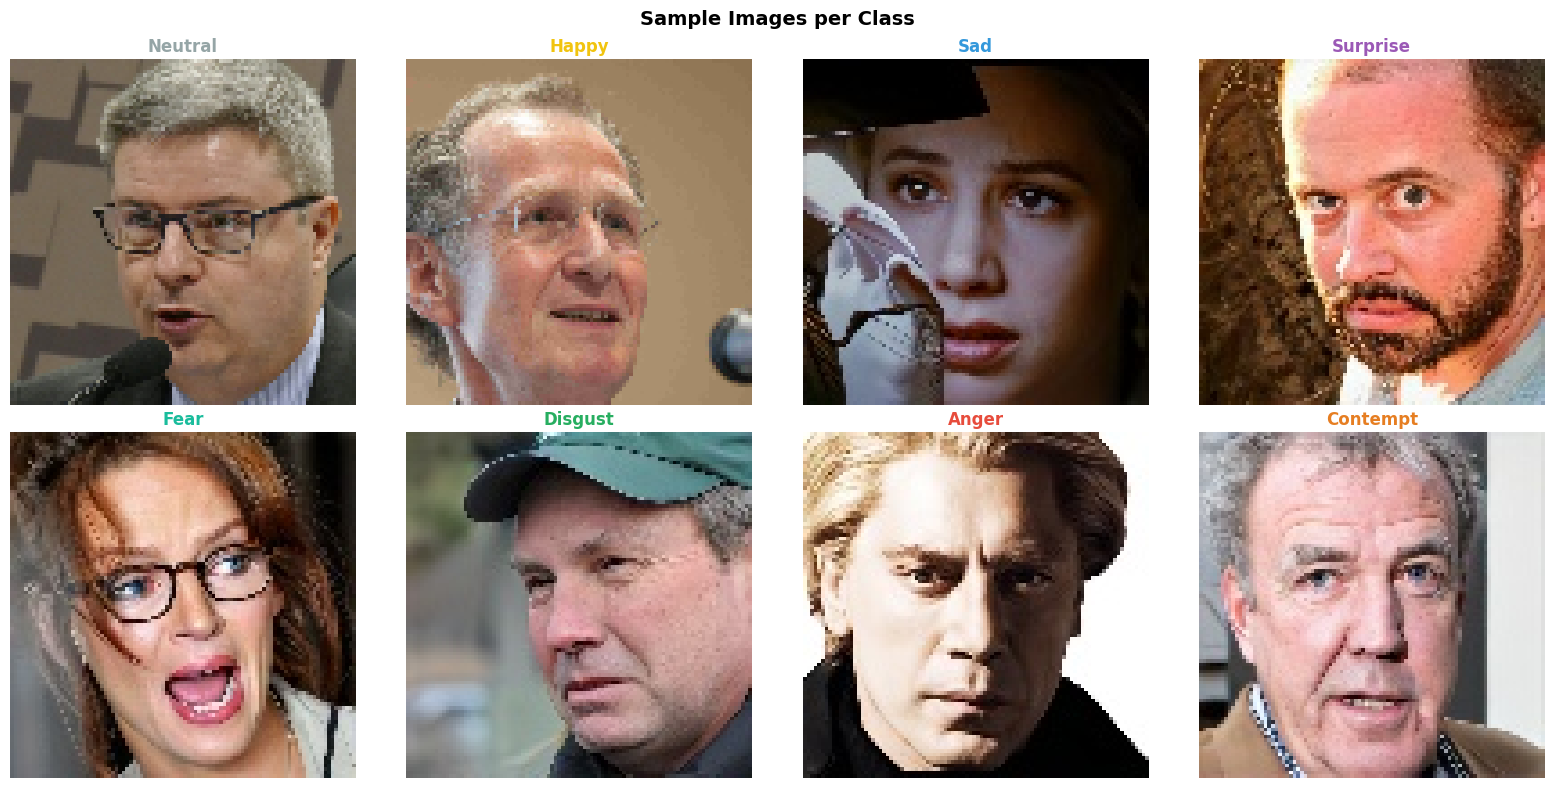

✅ Dataset analysis complete


In [28]:
# ============================================================
# CELL 3: Dataset Discovery, Cleaning & Statistics
# ============================================================
records = []
corrupt = []

for folder in sorted(DATASET_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    cls_key = folder.name.lower()
    if cls_key not in FOLDER_MAP:
        print(f'  ⚠️ Unknown folder: {folder.name}')
        continue
    cls_idx = FOLDER_MAP[cls_key]
    cls_name = CLASS_NAMES[cls_idx]

    for img_path in folder.iterdir():
        if img_path.suffix.lower() not in VALID_EXTS:
            continue
        # Quick validation
        try:
            img = Image.open(img_path)
            img.verify()
            records.append({
                'path': str(img_path),
                'class_name': cls_name,
                'class_idx': cls_idx,
            })
        except Exception:
            corrupt.append(str(img_path))

df = pd.DataFrame(records)
print(f'✅ Found {len(df):,} valid images ({len(corrupt)} corrupt removed)')
print(f'\nClass distribution:')
counts = df['class_name'].value_counts()
for cls in CLASS_NAMES:
    c = counts.get(cls, 0)
    bar = '█' * (c // 100)
    print(f'  {cls:10s}: {c:5d}  {bar}')

# Imbalance ratio
max_c = counts.max()
min_c = counts.min()
print(f'\n  Max/Min ratio: {max_c/min_c:.2f}x imbalance')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#95A5A6', '#F1C40F', '#3498DB', '#9B59B6',
          '#1ABC9C', '#27AE60', '#E74C3C', '#E67E22']

# Bar chart
ordered = [counts.get(c, 0) for c in CLASS_NAMES]
axes[0].bar(CLASS_NAMES, ordered, color=colors, edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(ordered):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Sample images
sample = df.groupby('class_idx').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
for i, row in sample.iterrows():
    img = Image.open(row['path']).convert('RGB').resize((112, 112))
    ax_idx = i if i < 4 else i
    # We'll show in a separate grid
axes[1].axis('off')
axes[1].set_title('Samples shown below', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / '01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Show sample images grid
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
for i, cls_idx in enumerate(range(NUM_CLASSES)):
    row, col = i // 4, i % 4
    sample_row = df[df['class_idx'] == cls_idx].sample(1, random_state=42).iloc[0]
    img = Image.open(sample_row['path']).convert('RGB')
    axes2[row, col].imshow(img)
    axes2[row, col].set_title(CLASS_NAMES[cls_idx], fontweight='bold', color=colors[cls_idx])
    axes2[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Dataset analysis complete')

In [6]:
# ============================================================
# CELL 4: Stratified Train/Val/Test Split (70/15/15)
# ============================================================
from sklearn.model_selection import StratifiedShuffleSplit

labels = df['class_idx'].values

# First split: 70% train, 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, labels))

# Second split: 50/50 of temp → 15% val, 15% test
temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(temp_idx, temp_labels))
val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train : {len(train_df):,} images')
print(f'Val   : {len(val_df):,} images')
print(f'Test  : {len(test_df):,} images')
print(f'Total : {len(train_df)+len(val_df)+len(test_df):,}')

# Per-class counts
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'\n{split_name}:')
    for cls in CLASS_NAMES:
        c = len(split_df[split_df['class_name'] == cls])
        print(f'  {cls:10s}: {c}')

# Save splits
train_df.to_csv(LOG_DIR / 'split_train.csv', index=False)
val_df.to_csv(LOG_DIR / 'split_val.csv', index=False)
test_df.to_csv(LOG_DIR / 'split_test.csv', index=False)
print(f'\n✅ Splits saved to {LOG_DIR}')

Train : 20,329 images
Val   : 4,356 images
Test  : 4,357 images
Total : 29,042

Train:
  Neutral   : 3588
  Happy     : 3531
  Sad       : 2164
  Surprise  : 2827
  Fear      : 2223
  Disgust   : 1734
  Anger     : 2252
  Contempt  : 2010

Val:
  Neutral   : 769
  Happy     : 756
  Sad       : 463
  Surprise  : 606
  Fear      : 476
  Disgust   : 372
  Anger     : 483
  Contempt  : 431

Test:
  Neutral   : 769
  Happy     : 757
  Sad       : 464
  Surprise  : 606
  Fear      : 477
  Disgust   : 371
  Anger     : 483
  Contempt  : 430

✅ Splits saved to emonext_outputs/logs


---
## 🔄 Augmentation Pipeline
Strong augmentation is critical for from-scratch training since the model has no prior knowledge of visual features.

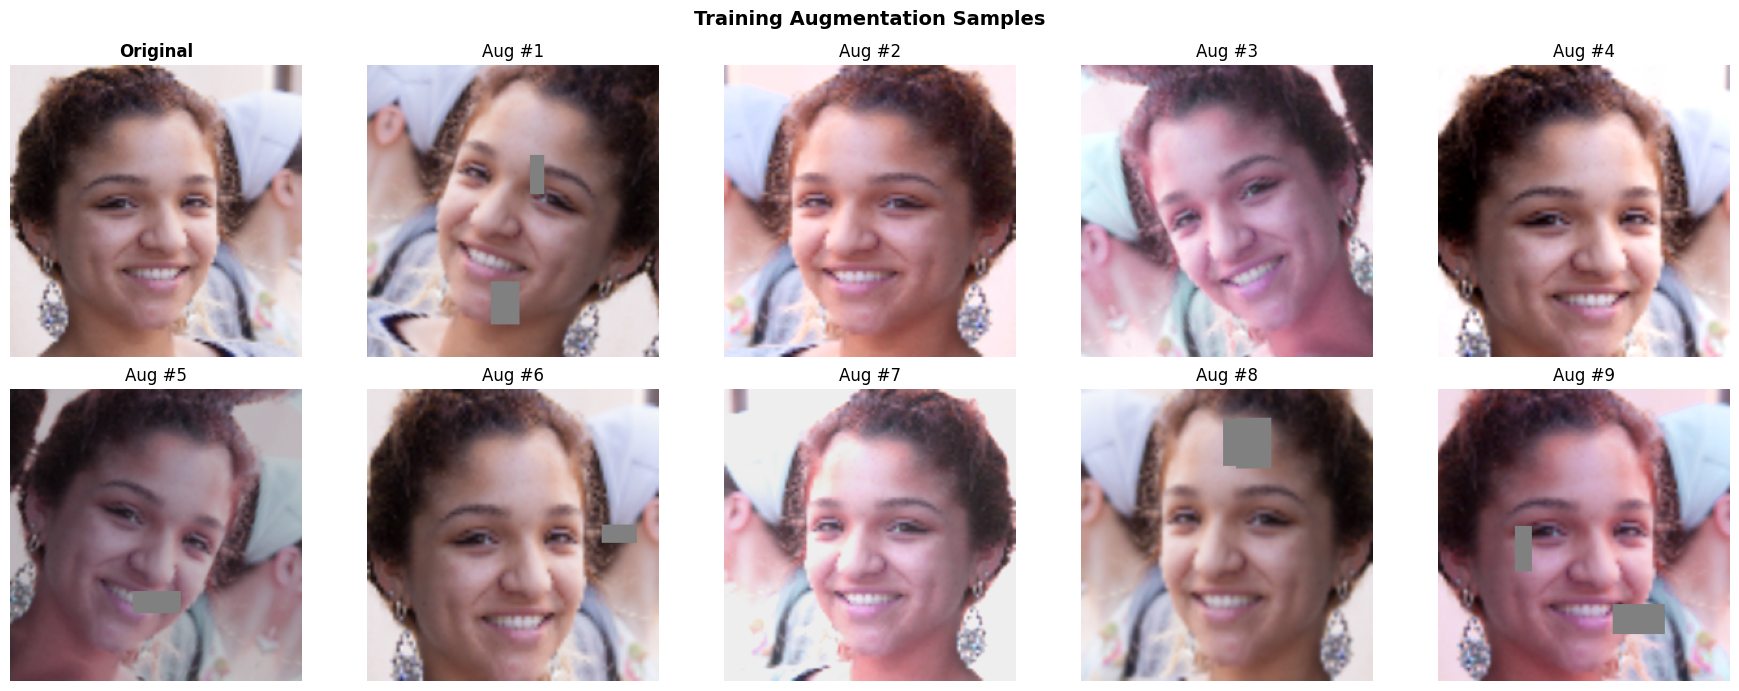

✅ Augmentation pipeline ready


In [29]:
# ============================================================
# CELL 5: Augmentation Pipeline (albumentations v2.0)
# ============================================================
# Strong augmentation for from-scratch training
TRAIN_AUG = A.Compose([
    A.RandomResizedCrop(
        size=(CFG['IMG_SIZE'], CFG['IMG_SIZE']),
        scale=(0.75, 1.0), ratio=(0.9, 1.1), p=1.0
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=CFG['ROTATION_LIMIT'], border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.Perspective(scale=(0.02, 0.06), p=0.3),
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=30),
    ], p=0.6),
    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.05)),
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=(3, 5)),
    ], p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(10, 40),
        hole_width_range=(10, 40),
        fill=128, p=0.3
    ),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])

VAL_AUG = A.Compose([
    A.Resize(CFG['IMG_SIZE'], CFG['IMG_SIZE']),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])

# Visualize augmentations
sample_path = train_df.iloc[0]['path']
sample_img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
if sample_img is None:
    sample_img = np.array(Image.open(sample_path).convert('RGB'))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes[0, 0].imshow(cv2.resize(sample_img, (224, 224)))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

aug_only = A.Compose([t for t in TRAIN_AUG.transforms[:-2]])  # skip Normalize+ToTensor
for i in range(1, 10):
    r, c = i // 5, i % 5
    aug_img = aug_only(image=sample_img)['image']
    axes[r, c].imshow(aug_img)
    axes[r, c].set_title(f'Aug #{i}')
    axes[r, c].axis('off')

plt.suptitle('Training Augmentation Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Augmentation pipeline ready')

---
## 📊 Dataset Class & DataLoaders

In [31]:
# ============================================================
# CELL 6: Dataset Class & DataLoaders with Weighted Sampling
# ============================================================

class FERDataset(Dataset):
    """Facial Expression Recognition Dataset."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['path']
        label = int(row['class_idx'])

        # Load image
        img = cv2.imread(path)
        if img is None:
            try:
                img = np.array(Image.open(path).convert('RGB'))
            except:
                img = np.zeros((CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label

# Create datasets
train_ds = FERDataset(train_df, TRAIN_AUG)
val_ds   = FERDataset(val_df, VAL_AUG)
test_ds  = FERDataset(test_df, VAL_AUG)

# Weighted sampler for class imbalance
train_counts = train_df['class_idx'].value_counts().sort_index()
class_weights = 1.0 / train_counts.values.astype(float)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
sample_weights = [class_weights[label] for label in train_df['class_idx'].values]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

LOADER_KW = dict(
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=CFG['PIN_MEMORY'],
    persistent_workers=CFG['NUM_WORKERS'] > 0,
)

train_loader = DataLoader(train_ds, batch_size=CFG['BATCH_SIZE'],
                          sampler=sampler, drop_last=True, **LOADER_KW)
val_loader   = DataLoader(val_ds, batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, **LOADER_KW)
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, **LOADER_KW)

print(f'✅ DataLoaders ready')
print(f'   Train: {len(train_loader)} batches × {CFG["BATCH_SIZE"]} = ~{len(train_loader)*CFG["BATCH_SIZE"]:,} samples/epoch')
print(f'   Val  : {len(val_loader)} batches')
print(f'   Test : {len(test_loader)} batches')
print(f'   Class weights: {class_weights.round(3)}')

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f'   Batch shape: {imgs.shape}, labels: {labels.shape}')
print(f'   Value range: [{imgs.min():.2f}, {imgs.max():.2f}]')

✅ DataLoaders ready
   Train: 847 batches × 24 = ~20,328 samples/epoch
   Val  : 182 batches
   Test : 182 batches
   Class weights: [0.666 0.677 1.105 0.846 1.076 1.379 1.062 1.19 ]
   Batch shape: torch.Size([24, 3, 224, 224]), labels: torch.Size([24])
   Value range: [-1.00, 1.00]


---
## 🧠 EmoNeXt Architecture — Designed for From-Scratch FER

### Novel Components

1. **Overlapping Conv Stem** — Strided convolutions (no aggressive pooling) preserving spatial detail
2. **EmoNeXt Block** — Inverted residual with depthwise-separable convolutions + SE attention + DropPath
3. **Multi-Frequency Spatial Attention (MFSA)** — Multi-scale dilated convolutions capture expression cues at different spatial frequencies (wrinkle textures vs. muscle movements vs. face shape)
4. **Facial Region-Aware Pooling (FRAP)** — 4-quadrant pooling (eyes-left, eyes-right, mouth-left, mouth-right) + global pooling with learnable region gates
5. **Adaptive Focal Loss** — Per-class learnable γ for automatic hard example mining

### Architecture Diagram
```
Input 224×224×3
    │
    ▼
[Overlapping Conv Stem] → 56×56×64
    │
    ▼
[Stage 1] 2× EmoNeXt Block → 56×56×64  ──→ Downsample
    │
    ▼
[Stage 2] 3× EmoNeXt Block → 28×28×128 ──→ Downsample
    │
    ▼
[Stage 3] 4× EmoNeXt Block + MFSA → 14×14×256 ──→ Downsample
    │
    ▼
[Stage 4] 2× EmoNeXt Block + MFSA → 7×7×384
    │
    ▼
[FRAP] 4-quadrant + global pooling → 5×384 = 1920
    │
    ▼
[Head] Linear(1920→512) → GELU → Dropout → Linear(512→8)
```

In [32]:
# ============================================================
# CELL 7: EmoNeXt Architecture — 100% From Scratch
# ============================================================

# ── DropPath (Stochastic Depth) ─────────────────────────────
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device, dtype=x.dtype))
        return x * mask / keep


# ── Squeeze-and-Excite Channel Attention ────────────────────
class SqueezeExcite(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(channels // reduction, 16)
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, mid),
            nn.GELU(),
            nn.Linear(mid, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(x).view(x.size(0), -1, 1, 1)


# ── EmoNeXt Block (Inverted Residual + SE + DropPath) ──────
class EmoNeXtBlock(nn.Module):
    """
    Core building block of EmoNeXt.
    Depthwise separable convolution with inverted bottleneck,
    Squeeze-Excite attention, and stochastic depth.
    """
    def __init__(self, channels, expand_ratio=3, se_ratio=4, drop_path=0.0):
        super().__init__()
        expanded = channels * expand_ratio
        self.block = nn.Sequential(
            # Depthwise conv
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            # Pointwise expand
            nn.Conv2d(channels, expanded, 1, bias=False),
            nn.BatchNorm2d(expanded),
            nn.GELU(),
            # Squeeze-Excite on expanded
            SqueezeExcite(expanded, reduction=se_ratio),
            # Pointwise project
            nn.Conv2d(expanded, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        return x + self.drop_path(self.block(x))


# ── Multi-Frequency Spatial Attention (MFSA) — NOVEL ───────
class MultiFrequencySpatialAttention(nn.Module):
    """
    Novel: Captures expression information at different spatial
    frequencies using parallel dilated depthwise convolutions.

    Low dilation  → fine textures (wrinkles, crow's feet)
    Medium dilation → muscle movements (smile lines, furrowed brow)
    High dilation → overall face shape & pose
    """
    def __init__(self, channels):
        super().__init__()
        # Three parallel frequency branches
        self.freq_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=d, dilation=d,
                          groups=channels, bias=False),
                nn.BatchNorm2d(channels),
                nn.GELU(),
            ) for d in [1, 2, 3]  # fine, medium, coarse
        ])
        # Learned frequency fusion
        self.fuse = nn.Sequential(
            nn.Conv2d(channels * 3, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        freq_outs = [branch(x) for branch in self.freq_branches]
        gate = self.fuse(torch.cat(freq_outs, dim=1))
        return x * gate + x  # Residual gating


# ── Downsampling Layer ──────────────────────────────────────
class Downsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.conv(x)


# ── Facial Region-Aware Pooling (FRAP) — NOVEL ─────────────
class FacialRegionAwarePooling(nn.Module):
    """
    Novel: Pools features from 4 facial quadrants + global.
    Each region corresponds to expression-relevant areas:
      Top-left / Top-right → eye regions
      Bottom-left / Bottom-right → mouth regions
    Learnable gates weight each region's importance.
    """
    def __init__(self, channels, num_regions=4):
        super().__init__()
        self.num_regions = num_regions
        self.gate = nn.Sequential(
            nn.Linear(channels * (num_regions + 1), 256),
            nn.GELU(),
            nn.Linear(256, num_regions + 1),
            nn.Softmax(dim=-1),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        # Global pool
        global_feat = F.adaptive_avg_pool2d(x, 1).flatten(1)  # B×C

        # 4-quadrant pools
        h_mid, w_mid = H // 2, W // 2
        regions = [
            x[:, :, :h_mid, :w_mid],      # top-left (left eye)
            x[:, :, :h_mid, w_mid:],       # top-right (right eye)
            x[:, :, h_mid:, :w_mid],       # bottom-left (left mouth)
            x[:, :, h_mid:, w_mid:],       # bottom-right (right mouth)
        ]
        region_feats = [F.adaptive_avg_pool2d(r, 1).flatten(1) for r in regions]

        # All features
        all_feats = [global_feat] + region_feats  # list of 5 × B×C
        all_cat = torch.cat(all_feats, dim=-1)    # B×(5C)

        # Learned gating
        gates = self.gate(all_cat)                # B×5
        stacked = torch.stack(all_feats, dim=1)   # B×5×C
        fused = (stacked * gates.unsqueeze(-1)).reshape(B, -1)  # B×(5C)

        return fused, gates


# ══════════════════════════════════════════════════════════════
# MAIN ARCHITECTURE: EmoNeXt
# ══════════════════════════════════════════════════════════════
class EmoNeXt(nn.Module):
    """
    EmoNeXt: Emotion Recognition NeXt
    Novel lightweight network for from-scratch FER.

    Key features:
    1. Overlapping conv stem (preserves spatial detail)
    2. EmoNeXt blocks with inverted residual + SE + DropPath
    3. Multi-Frequency Spatial Attention (MFSA)
    4. Facial Region-Aware Pooling (FRAP)
    5. 100% from scratch — no pretrained weights
    """

    def __init__(self, num_classes=8, channels=[64, 128, 256, 384],
                 depths=[2, 3, 4, 2], expand_ratio=3, se_ratio=4,
                 dropout=0.2, drop_path=0.15, use_mfsa=True):
        super().__init__()
        self.num_classes = num_classes

        # ── Overlapping Conv Stem ────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(3, channels[0] // 2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(channels[0] // 2),
            nn.GELU(),
            nn.Conv2d(channels[0] // 2, channels[0], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(channels[0]),
            nn.GELU(),
        )  # 224→56

        # ── Build stages ─────────────────────────────────────
        total_blocks = sum(depths)
        dp_rates = [x.item() for x in torch.linspace(0, drop_path, total_blocks)]
        block_idx = 0

        self.stages = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        for stage_i in range(4):
            blocks = []
            for j in range(depths[stage_i]):
                blocks.append(EmoNeXtBlock(
                    channels[stage_i], expand_ratio, se_ratio,
                    drop_path=dp_rates[block_idx]
                ))
                block_idx += 1
            # Add MFSA to last two stages
            if use_mfsa and stage_i >= 2:
                blocks.append(MultiFrequencySpatialAttention(channels[stage_i]))
            self.stages.append(nn.Sequential(*blocks))

            # Downsample between stages (not after last)
            if stage_i < 3:
                self.downsamples.append(Downsample(channels[stage_i], channels[stage_i + 1]))

        # ── FRAP Head ────────────────────────────────────────
        self.frap = FacialRegionAwarePooling(channels[-1])
        frap_dim = channels[-1] * 5  # 4 regions + 1 global

        self.head = nn.Sequential(
            nn.Linear(frap_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

        # ── Feature extractor for embeddings ─────────────────
        self.embed_proj = nn.Linear(frap_dim, 256)

        # ── Initialize ALL weights from scratch ──────────────
        self._init_weights()

    def _init_weights(self):
        """Kaiming He initialization for from-scratch training."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward_features(self, x):
        x = self.stem(x)
        for i, stage in enumerate(self.stages):
            x = stage(x)
            if i < len(self.downsamples):
                x = self.downsamples[i](x)
        return x

    def forward(self, x):
        features = self.forward_features(x)   # B×384×7×7
        pooled, region_gates = self.frap(features)  # B×1920
        logits = self.head(pooled)
        embeddings = self.embed_proj(pooled)
        return {
            'logits': logits,
            'embeddings': embeddings,
            'region_gates': region_gates,
        }


# ══════════════════════════════════════════════════════════════
# Instantiate
# ══════════════════════════════════════════════════════════════
print('=' * 60)
print('🧠 BUILDING EmoNeXt (100% From Scratch)')
print('=' * 60)

model = EmoNeXt(
    num_classes=NUM_CLASSES,
    channels=CFG['CHANNELS'],
    depths=CFG['DEPTHS'],
    expand_ratio=CFG['EXPAND_RATIO'],
    se_ratio=CFG['SE_RATIO'],
    dropout=CFG['DROPOUT'],
    drop_path=CFG['DROP_PATH'],
    use_mfsa=CFG['USE_MFSA'],
).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n  Total params    : {total_p/1e6:.2f}M')
print(f'  Trainable params: {train_p/1e6:.2f}M (all — from scratch)')

# Forward pass test
model.eval()
with torch.no_grad():
    dummy = torch.randn(4, 3, CFG['IMG_SIZE'], CFG['IMG_SIZE']).to(DEVICE)
    out = model(dummy)

print(f'\n  ✅ Forward pass OK')
print(f'     logits       : {out["logits"].shape}')
print(f'     embeddings   : {out["embeddings"].shape}')
print(f'     region_gates : {out["region_gates"].shape}')

# VRAM check
if DEVICE.type == 'cuda':
    model.train()
    dummy = torch.randn(CFG['BATCH_SIZE'], 3, CFG['IMG_SIZE'], CFG['IMG_SIZE']).to(DEVICE)
    with torch.no_grad():
        _ = model(dummy)
    vram_used = torch.cuda.memory_allocated() / 1e9
    print(f'     VRAM (batch {CFG["BATCH_SIZE"]}): {vram_used:.2f} GB')
    del dummy; torch.cuda.empty_cache()

🧠 BUILDING EmoNeXt (100% From Scratch)

  Total params    : 10.41M
  Trainable params: 10.41M (all — from scratch)

  ✅ Forward pass OK
     logits       : torch.Size([4, 8])
     embeddings   : torch.Size([4, 256])
     region_gates : torch.Size([4, 5])
     VRAM (batch 24): 0.26 GB


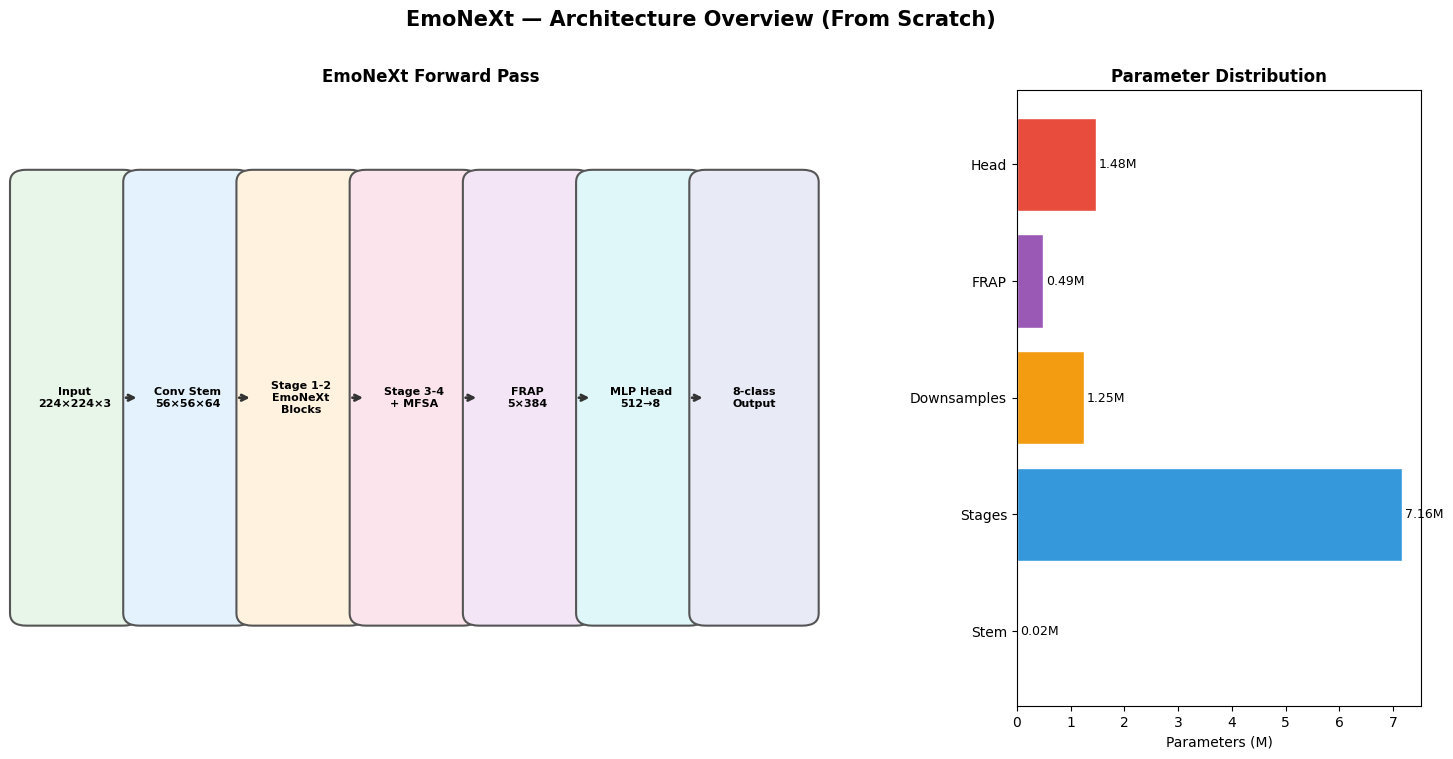

✅ Architecture visualization saved


In [33]:
# ============================================================
# CELL 8: Model Architecture Visualization
# ============================================================
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 8))
fig.suptitle('EmoNeXt — Architecture Overview (From Scratch)', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.3)

# ── Block diagram ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')
blocks = [
    ('Input\n224×224×3',    '#E8F5E9', 0.00),
    ('Conv Stem\n56×56×64', '#E3F2FD', 0.14),
    ('Stage 1-2\nEmoNeXt\nBlocks',   '#FFF3E0', 0.28),
    ('Stage 3-4\n+ MFSA',  '#FCE4EC', 0.42),
    ('FRAP\n5×384',         '#F3E5F5', 0.56),
    ('MLP Head\n512→8',    '#E0F7FA', 0.70),
    ('8-class\nOutput',     '#E8EAF6', 0.84),
]
for label, color, x in blocks:
    box = mpatches.FancyBboxPatch((x, 0.15), 0.12, 0.7,
        boxstyle='round,pad=0.02', facecolor=color, edgecolor='#555',
        linewidth=1.5, transform=ax1.transAxes, clip_on=False)
    ax1.add_patch(box)
    ax1.text(x + 0.06, 0.5, label, transform=ax1.transAxes,
             ha='center', va='center', fontsize=8, fontweight='bold')
    if x < 0.84:
        ax1.annotate('', xy=(x + 0.14, 0.5), xytext=(x + 0.12, 0.5),
                     xycoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax1.set_title('EmoNeXt Forward Pass', fontsize=12, fontweight='bold')

# ── Parameter distribution ─────────────────────────────
ax2 = fig.add_subplot(gs[1])
param_groups = {
    'Stem': sum(p.numel() for n, p in model.named_parameters() if 'stem' in n),
    'Stages': sum(p.numel() for n, p in model.named_parameters() if 'stages' in n),
    'Downsamples': sum(p.numel() for n, p in model.named_parameters() if 'downsample' in n),
    'FRAP': sum(p.numel() for n, p in model.named_parameters() if 'frap' in n),
    'Head': sum(p.numel() for n, p in model.named_parameters() if 'head' in n or 'embed' in n),
}
names = list(param_groups.keys())
sizes = [v / 1e6 for v in param_groups.values()]
colors_pg = ['#27AE60', '#3498DB', '#F39C12', '#9B59B6', '#E74C3C']
bars = ax2.barh(names, sizes, color=colors_pg, edgecolor='white')
ax2.set_xlabel('Parameters (M)')
ax2.set_title('Parameter Distribution', fontweight='bold')
for bar, s in zip(bars, sizes):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{s:.2f}M', va='center', fontsize=9)

plt.savefig(PLOT_DIR / '04_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Architecture visualization saved')

---
## 📉 Loss Functions
- **Cross-Entropy** with label smoothing
- **Adaptive Focal Loss** — per-class learnable focusing parameter γ

In [34]:
# ============================================================
# CELL 9: Loss Functions
# ============================================================

class AdaptiveFocalLoss(nn.Module):
    """
    Novel: Adaptive Focal Loss with per-class learnable gamma.
    Each class automatically learns its own focusing parameter:
      - Easy classes → higher gamma (focus more on hard examples)
      - Hard classes → lower gamma (avoid over-penalizing)
    """
    def __init__(self, num_classes, init_gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.log_gammas = nn.Parameter(
            torch.full((num_classes,), math.log(init_gamma))
        )
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Force float32 — focal math is unstable in float16 (AMP)
        logits = logits.float()
        gammas = torch.exp(self.log_gammas).clamp(0.5, 5.0)
        ce = F.cross_entropy(logits, targets, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce).clamp(min=1e-8, max=1.0 - 1e-8)
        gamma_t = gammas[targets]
        focal_weight = (1 - pt) ** gamma_t
        loss = (focal_weight * ce).mean()
        return torch.clamp(loss, max=100.0)

    def get_gammas(self):
        return torch.exp(self.log_gammas).clamp(0.5, 5.0).detach().cpu()


class CombinedLoss(nn.Module):
    """Combined CE + Adaptive Focal Loss."""
    def __init__(self, num_classes, focal_weight=0.5,
                 focal_gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.focal = AdaptiveFocalLoss(
            num_classes, init_gamma=focal_gamma,
            label_smoothing=label_smoothing
        )
        self.w = focal_weight

    def forward(self, logits, targets):
        # Force float32 — CE is also unstable in float16 with large logits
        logits = logits.float()
        loss_ce = self.ce(logits, targets)
        loss_focal = self.focal(logits, targets)
        total = (1 - self.w) * loss_ce + self.w * loss_focal
        return total, {
            'ce': loss_ce.item(),
            'focal': loss_focal.item(),
        }


criterion = CombinedLoss(
    num_classes=NUM_CLASSES,
    focal_weight=CFG['FOCAL_WEIGHT'],
    focal_gamma=CFG['FOCAL_GAMMA'],
    label_smoothing=CFG['LABEL_SMOOTHING'],
).to(DEVICE)

print('✅ Loss functions ready')
print(f'   CE weight   : {1 - CFG["FOCAL_WEIGHT"]:.1f}')
print(f'   Focal weight: {CFG["FOCAL_WEIGHT"]:.1f}')
print(f'   Focal γ init: {CFG["FOCAL_GAMMA"]}')
print(f'   Smoothing   : {CFG["LABEL_SMOOTHING"]}')

✅ Loss functions ready
   CE weight   : 0.5
   Focal weight: 0.5
   Focal γ init: 2.0
   Smoothing   : 0.1


---
## 🚂 Training Pipeline

In [35]:
# ============================================================
# CELL 10: Training Pipeline — Optimizer, Scheduler, Mixup
# ============================================================

# ── Mixup & CutMix ───────────────────────────────────────
def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    B, C, H, W = x.shape
    cut_rat = np.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    idx = torch.randperm(B, device=x.device)
    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return mixed, y, y[idx], lam

# ── Optimizer ─────────────────────────────────────────────
# Separate weight decay for BN/bias vs conv/linear
decay_params = []
no_decay_params = []
for name, param in list(model.named_parameters()) + list(criterion.named_parameters()):
    if not param.requires_grad:
        continue
    if 'bn' in name or 'norm' in name or 'bias' in name or 'gamma' in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = optim.AdamW([
    {'params': decay_params, 'weight_decay': CFG['WEIGHT_DECAY']},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=CFG['LR'], betas=(0.9, 0.999), eps=1e-8)

# ── Scheduler: Warmup + Cosine ────────────────────────────
steps_per_epoch = math.ceil(len(train_loader) / CFG['GRAD_ACCUM'])
total_steps = CFG['EPOCHS'] * steps_per_epoch
warmup_steps = CFG['WARMUP_EPOCHS'] * steps_per_epoch

def lr_schedule(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(CFG['LR_MIN'] / CFG['LR'],
               0.5 * (1 + math.cos(math.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_schedule)
scaler = GradScaler('cuda', enabled=CFG['USE_AMP'] and DEVICE.type == 'cuda')

print('✅ Training pipeline ready')
print(f'   Optimizer       : AdamW (LR={CFG["LR"]}, WD={CFG["WEIGHT_DECAY"]})')
print(f'   Scheduler       : Warmup({CFG["WARMUP_EPOCHS"]}ep) + Cosine')
print(f'   Steps/epoch     : {steps_per_epoch}')
print(f'   Total steps     : {total_steps}')
print(f'   Mixup α         : {CFG["MIXUP_ALPHA"]}')
print(f'   CutMix α        : {CFG["CUTMIX_ALPHA"]}')
print(f'   Grad accum      : {CFG["GRAD_ACCUM"]} (eff batch {EFF_BATCH})')

# ── Training State ────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'val_f1': [], 'lr': [],
    'loss_ce': [], 'loss_focal': [],
}
best_val_acc = 0.0
best_val_f1 = 0.0
patience_ctr = 0
best_model_state = None

✅ Training pipeline ready
   Optimizer       : AdamW (LR=0.001, WD=0.0001)
   Scheduler       : Warmup(5ep) + Cosine
   Steps/epoch     : 212
   Total steps     : 21200
   Mixup α         : 0.3
   CutMix α        : 1.0
   Grad accum      : 4 (eff batch 96)


In [36]:
# ============================================================
# CELL 11: Training & Evaluation Functions
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    scheduler, device, grad_accum, epoch):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    comp = defaultdict(float)
    n_batches = 0
    use_mixup = epoch > CFG['WARMUP_EPOCHS']

    optimizer.zero_grad()

    for step, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Mixup / CutMix
        mixed = False
        if use_mixup and random.random() < CFG['MIXUP_PROB']:
            if random.random() < 0.5:
                imgs, labels_a, labels_b, lam = mixup_data(imgs, labels, CFG['MIXUP_ALPHA'])
            else:
                imgs, labels_a, labels_b, lam = cutmix_data(imgs, labels, CFG['CUTMIX_ALPHA'])
            mixed = True

        with autocast('cuda', enabled=CFG['USE_AMP'] and device.type == 'cuda'):
            outputs = model(imgs)
            logits = outputs['logits']

            if mixed:
                loss_a, comp_a = criterion(logits, labels_a)
                loss_b, comp_b = criterion(logits, labels_b)
                loss = lam * loss_a + (1 - lam) * loss_b
                batch_comp = {k: lam * comp_a[k] + (1 - lam) * comp_b.get(k, 0) for k in comp_a}
            else:
                loss, batch_comp = criterion(logits, labels)

        # NaN guard — skip batch if loss is NaN/Inf
        if not torch.isfinite(loss):
            optimizer.zero_grad()
            continue

        loss_scaled = loss / grad_accum
        scaler.scale(loss_scaled).backward()

        if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        # Accuracy
        preds = logits.argmax(1)
        if mixed:
            correct += (lam * (preds == labels_a).float() +
                       (1 - lam) * (preds == labels_b).float()).sum().item()
        else:
            correct += (preds == labels).sum().item()
        total += labels.size(0)

        total_loss += loss.item()
        n_batches += 1
        for k, v in batch_comp.items():
            comp[k] += v

    return (total_loss / max(n_batches, 1),
            correct / max(total, 1),
            {k: v / max(n_batches, 1) for k, v in comp.items()})


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    n_batches = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast('cuda', enabled=CFG['USE_AMP'] and device.type == 'cuda'):
            outputs = model(imgs)
            logits = outputs['logits']
            loss, _ = criterion(logits, labels)

        probs = F.softmax(logits.float(), dim=1)
        preds = logits.argmax(1)
        if torch.isfinite(loss):
            total_loss += loss.item()
        n_batches += 1
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / max(n_batches, 1), acc, f1, all_preds, all_labels, all_probs


print('✅ Training & evaluation functions defined')

✅ Training & evaluation functions defined


---
## 🔄 Recovery Cell (Run this INSTEAD of the Training Loop after interrupt)
Load saved checkpoint + reconstruct history from disk. **Skip the training loop cell below.**

In [15]:
# ============================================================
# CELL 11.5: Recovery — Load best model & history from disk
# Run this INSTEAD of re-training after an interrupt
# ============================================================

# Load best checkpoint (epoch 37 weights)
ckpt_path = MODEL_DIR / 'best_model.pth'
assert ckpt_path.exists(), f'❌ No checkpoint found at {ckpt_path}'

ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
best_model_state = ckpt['model_state']
best_val_acc = ckpt['val_acc']
best_val_f1 = ckpt['val_f1']
best_epoch = ckpt.get('epoch', '?')

model.load_state_dict(best_model_state)
model.to(DEVICE)
print(f'✅ Loaded best model from epoch {best_epoch}')
print(f'   Val Acc: {best_val_acc*100:.2f}%')
print(f'   Val F1 : {best_val_f1*100:.2f}%')

# Reconstruct history from checkpoint_ep030 (has real training data)
# The CSV was from a broken earlier run — checkpoint has the real history
hist_ckpt_path = MODEL_DIR / 'checkpoint_ep030.pth'
assert hist_ckpt_path.exists(), f'❌ No checkpoint found at {hist_ckpt_path}'

hist_ckpt = torch.load(hist_ckpt_path, map_location='cpu', weights_only=False)
history = hist_ckpt['history']

# Ensure loss component lists exist for plotting
if not history.get('loss_ce'):
    history['loss_ce'] = [0.0] * len(history['train_loss'])
if not history.get('loss_focal'):
    history['loss_focal'] = [0.0] * len(history['train_loss'])

n_epochs = len(history['train_loss'])
print(f'✅ Loaded training history: {n_epochs} epochs (from checkpoint)')

print(f'\n📊 Training Summary ({n_epochs} epochs):')
print(f'   Final Train Loss: {history["train_loss"][-1]:.4f}')
print(f'   Final Train Acc : {history["train_acc"][-1]*100:.2f}%')
print(f'   Final Val Loss  : {history["val_loss"][-1]:.4f}')
print(f'   Final Val Acc   : {history["val_acc"][-1]*100:.2f}%')
print(f'   Final Val F1    : {history["val_f1"][-1]*100:.2f}%')
print(f'   Best Val Acc    : {best_val_acc*100:.2f}%  (epoch {best_epoch})')
print(f'   Best Val F1     : {best_val_f1*100:.2f}%  (epoch {best_epoch})')

del hist_ckpt; gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()

print(f'\n✅ Ready — skip training loop and run cells below (curves, evaluation, etc.)')

✅ Loaded best model from epoch 37
   Val Acc: 72.73%
   Val F1 : 69.56%
✅ Loaded training history: 30 epochs (from checkpoint)

📊 Training Summary (30 epochs):
   Final Train Loss: 0.8592
   Final Train Acc : 63.14%
   Final Val Loss  : 0.7038
   Final Val Acc   : 70.06%
   Final Val F1    : 66.87%
   Best Val Acc    : 72.73%  (epoch 37)
   Best Val F1     : 69.56%  (epoch 37)

✅ Ready — skip training loop and run cells below (curves, evaluation, etc.)


In [37]:
# ============================================================
# CELL 12: Training Loop
# ============================================================
model.to(DEVICE)
start_time = time.time()
log_rows = []

print('=' * 115)
print('{:>5} | {:>10} | {:>8} | {:>8} | {:>9} | {:>8} | {:>7} | {:>7} | {:>10} | {:>5}'.format(
    'Epoch', 'Train Loss', 'CE Loss', 'Focal', 'Train Acc', 'Val Loss',
    'Val Acc', 'Val F1', 'LR', 'Time'
))
print('=' * 115)

for epoch in range(1, CFG['EPOCHS'] + 1):
    ep_start = time.time()

    train_loss, train_acc, comp_losses = train_one_epoch(
        model, train_loader, optimizer, criterion,
        scaler, scheduler, DEVICE, CFG['GRAD_ACCUM'], epoch
    )

    val_loss, val_acc, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    ep_time = time.time() - ep_start
    curr_lr = optimizer.param_groups[0]['lr']

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(curr_lr)
    history['loss_ce'].append(comp_losses.get('ce', 0))
    history['loss_focal'].append(comp_losses.get('focal', 0))

    cls_loss = comp_losses.get('ce', float('nan'))
    focal_loss = comp_losses.get('focal', float('nan'))

    log_rows.append({
        'epoch': epoch, 'train_loss': train_loss,
        'val_loss': val_loss, 'train_acc': train_acc,
        'val_acc': val_acc, 'val_f1': val_f1,
        'lr': curr_lr, 'time_s': ep_time,
    })

    # Best model
    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0
        torch.save({
            'epoch': epoch,
            'model_state': best_model_state,
            'val_acc': best_val_acc,
            'val_f1': best_val_f1,
            'cfg': CFG,
        }, MODEL_DIR / 'best_model.pth')
    else:
        patience_ctr += 1

    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'history': history,
        }, MODEL_DIR / f'checkpoint_ep{epoch:03d}.pth')

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    star = '★' if is_best else ''
    print(f"{epoch:5d} | {train_loss:10.4f} | {cls_loss:8.4f} | {focal_loss:8.4f} | {train_acc*100:8.1f}% | {val_loss:8.4f} | {val_acc*100:6.1f}% | {val_f1*100:6.1f}% | {curr_lr:10.6f} | {ep_time:4.0f}s {star}")

    if patience_ctr >= CFG['EARLY_STOP']:
        print(f'\n⏹️  Early stopping at epoch {epoch}')
        break

print('=' * 115)
total_time = time.time() - start_time
print(f'\n✅ Training complete in {total_time/60:.1f} min')
print(f'   Best Val Acc: {best_val_acc*100:.2f}%')
print(f'   Best Val F1 : {best_val_f1*100:.2f}%')

# Save log
pd.DataFrame(log_rows).to_csv(LOG_DIR / 'training_log.csv', index=False)

# Adaptive focal gammas
gammas = criterion.focal.get_gammas()
print(f'\n   Learned Focal Gammas:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'     {cls:10s}: γ = {gammas[i]:.3f}')

Epoch | Train Loss |  CE Loss |    Focal | Train Acc | Val Loss | Val Acc |  Val F1 |         LR |  Time
    1 |     1.8424 |   2.0859 |   1.5990 |     14.7% |   1.6636 |   24.7% |   18.2% |   0.000201 |  320s ★
    2 |     1.6552 |   1.9200 |   1.3904 |     23.9% |   1.3744 |   36.6% |   30.6% |   0.000401 |  316s ★
    3 |     1.4690 |   1.7593 |   1.1788 |     33.9% |   1.1775 |   48.4% |   41.0% |   0.000601 |  315s ★
    4 |     1.3015 |   1.6184 |   0.9847 |     42.8% |   1.0463 |   54.7% |   48.7% |   0.000801 |  314s ★
    5 |     1.1840 |   1.5359 |   0.8320 |     47.5% |   1.0302 |   54.2% |   49.2% |   0.001000 |  314s ★
    6 |     1.1860 |   1.5832 |   0.7889 |     45.8% |   0.8816 |   60.4% |   55.8% |   0.001000 |  315s ★
    7 |     1.0994 |   1.5411 |   0.6578 |     49.1% |   0.8612 |   61.2% |   55.9% |   0.000999 |  314s ★
    8 |     1.0646 |   1.5189 |   0.6103 |     50.9% |   0.8466 |   62.5% |   57.8% |   0.000998 |  315s ★
    9 |     1.0466 |   1.5033 |   0.589

KeyboardInterrupt: 

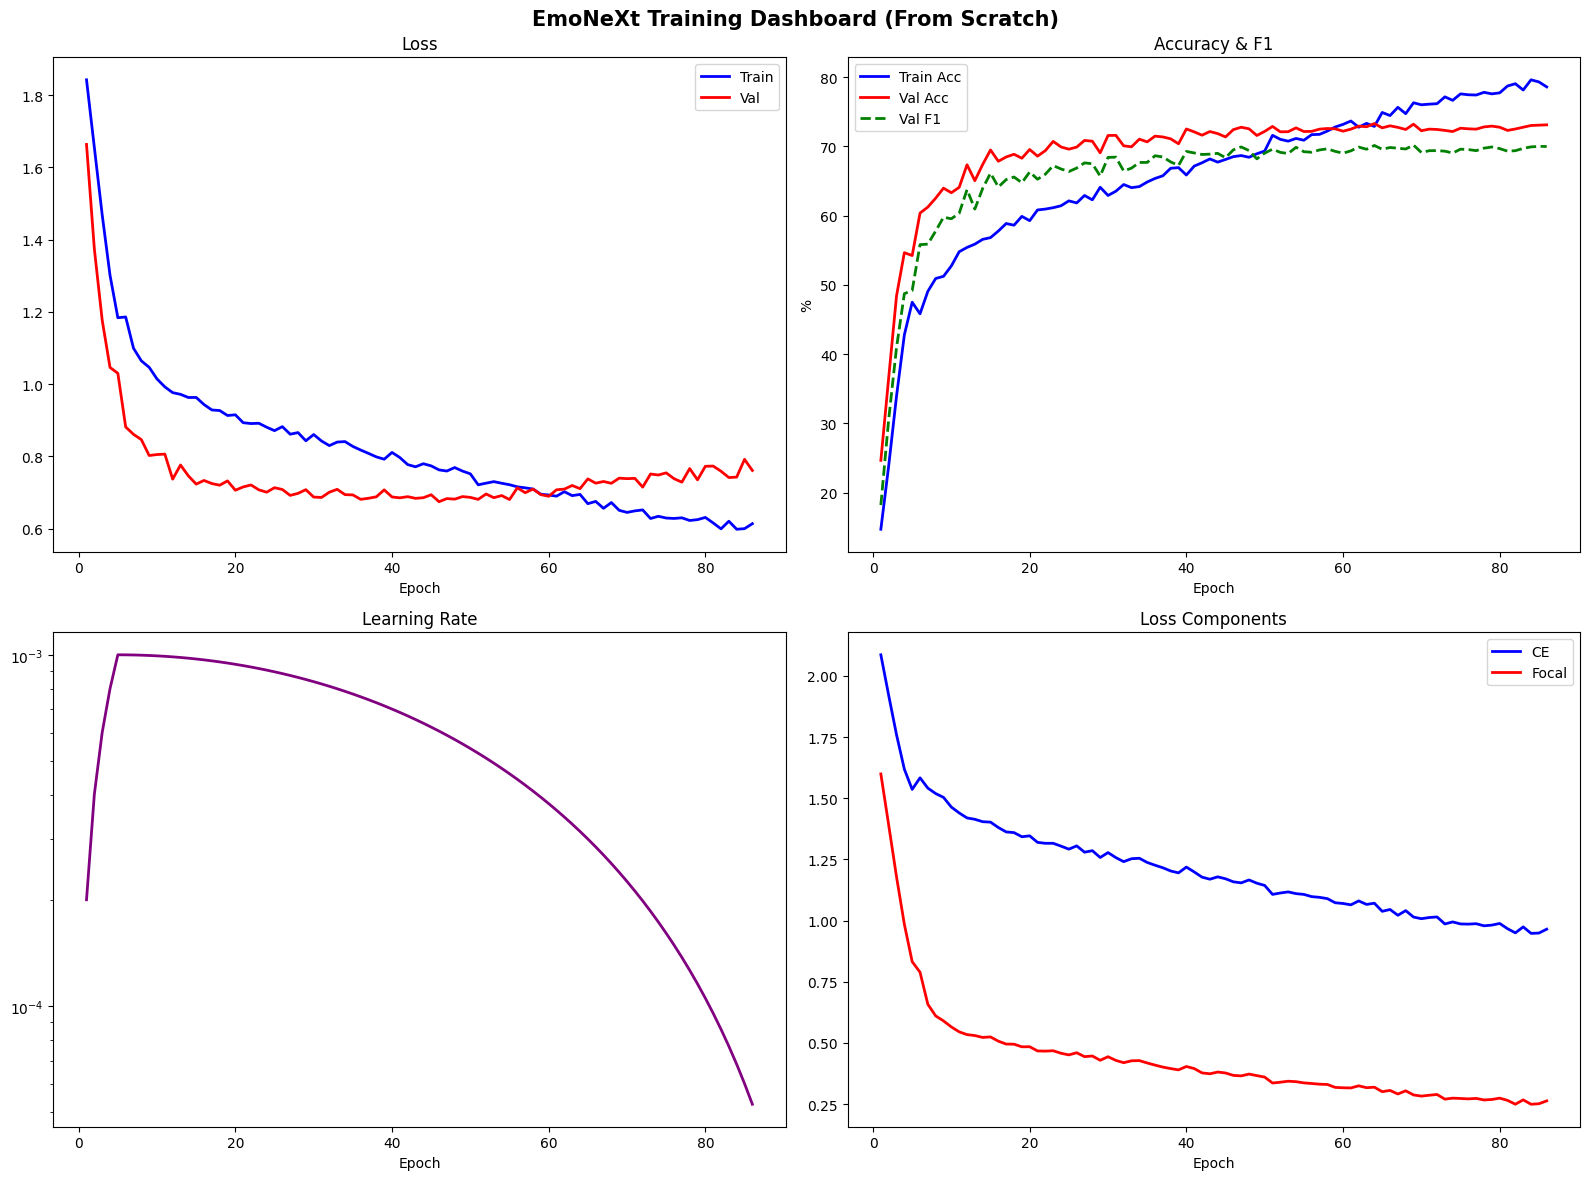

In [38]:
# ============================================================
# CELL 13: Training Curves
# ============================================================
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EmoNeXt Training Dashboard (From Scratch)', fontsize=15, fontweight='bold')

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', lw=2, label='Train')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', lw=2, label='Val')
axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')

# Accuracy
axes[0, 1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-', lw=2, label='Train Acc')
axes[0, 1].plot(epochs_range, [a*100 for a in history['val_acc']], 'r-', lw=2, label='Val Acc')
axes[0, 1].plot(epochs_range, [f*100 for f in history['val_f1']], 'g--', lw=2, label='Val F1')
axes[0, 1].set_title('Accuracy & F1'); axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('%')

# LR
axes[1, 0].plot(epochs_range, history['lr'], 'purple', lw=2)
axes[1, 0].set_title('Learning Rate'); axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_yscale('log')

# Loss components
axes[1, 1].plot(epochs_range, history['loss_ce'], 'b-', lw=2, label='CE')
axes[1, 1].plot(epochs_range, history['loss_focal'], 'r-', lw=2, label='Focal')
axes[1, 1].set_title('Loss Components'); axes[1, 1].legend(); axes[1, 1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(PLOT_DIR / '05_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Evaluation on Test Set

In [39]:
# ============================================================
# CELL 14: Full Evaluation on Test Set
# ============================================================
# Load best model
model.load_state_dict(best_model_state)
model.eval()

test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('=' * 60)
print('📊 TEST SET RESULTS (EmoNeXt — From Scratch)')
print('=' * 60)
print(f'  Accuracy : {test_acc*100:.2f}%')
print(f'  F1-Macro : {test_f1*100:.2f}%')
print(f'  Loss     : {test_loss:.4f}')

print('\n' + classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES, digits=4
))

📊 TEST SET RESULTS (EmoNeXt — From Scratch)
  Accuracy : 72.85%
  F1-Macro : 69.66%
  Loss     : 0.7316

              precision    recall  f1-score   support

     Neutral     0.9087    0.9064    0.9076       769
       Happy     0.9530    0.9366    0.9447       757
         Sad     0.6535    0.5690    0.6083       464
    Surprise     0.6788    0.6452    0.6616       606
        Fear     0.6096    0.6122    0.6109       477
     Disgust     0.5338    0.5957    0.5631       371
       Anger     0.5843    0.6170    0.6002       483
    Contempt     0.6523    0.7023    0.6764       430

    accuracy                         0.7285      4357
   macro avg     0.6967    0.6980    0.6966      4357
weighted avg     0.7313    0.7285    0.7292      4357



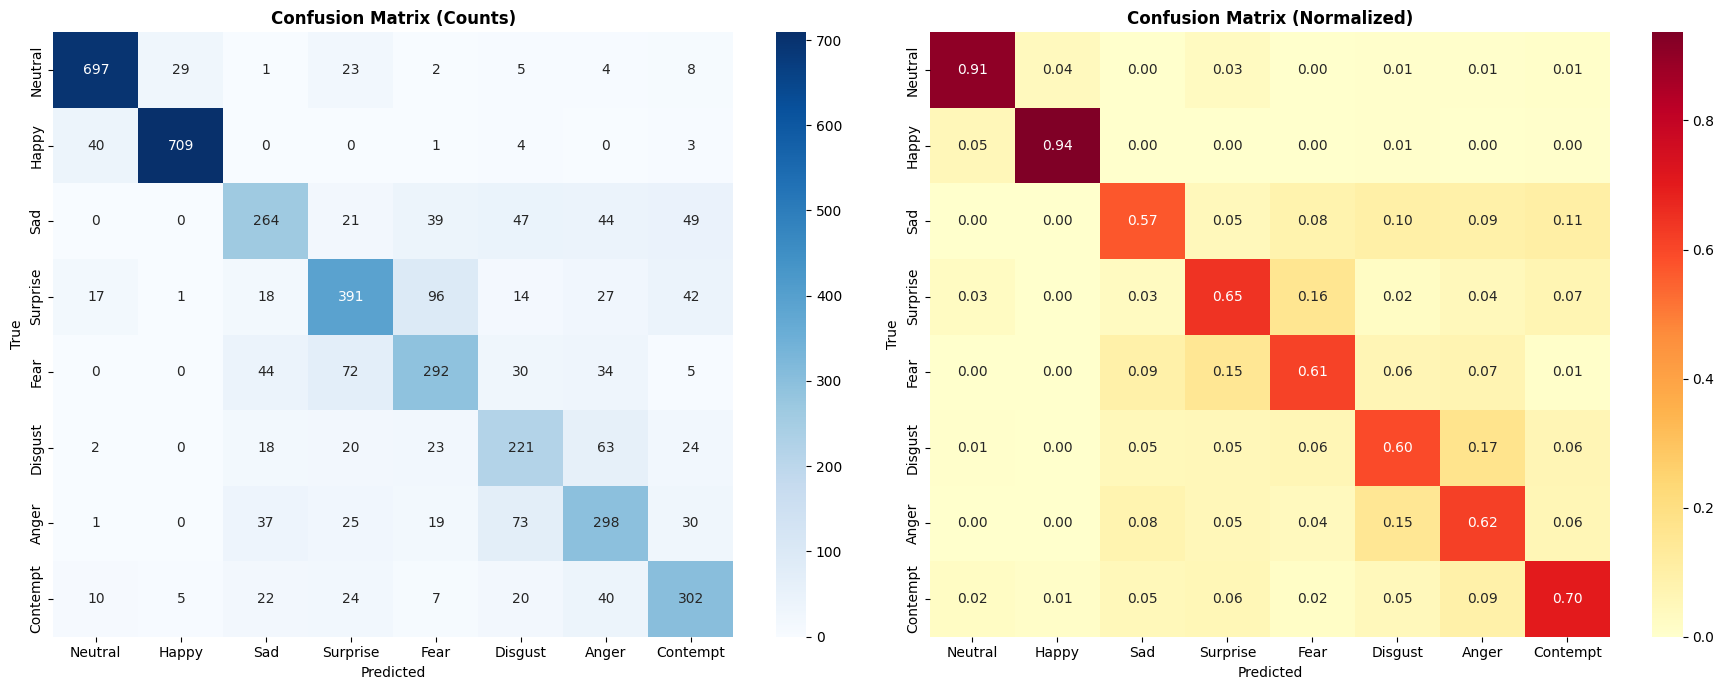

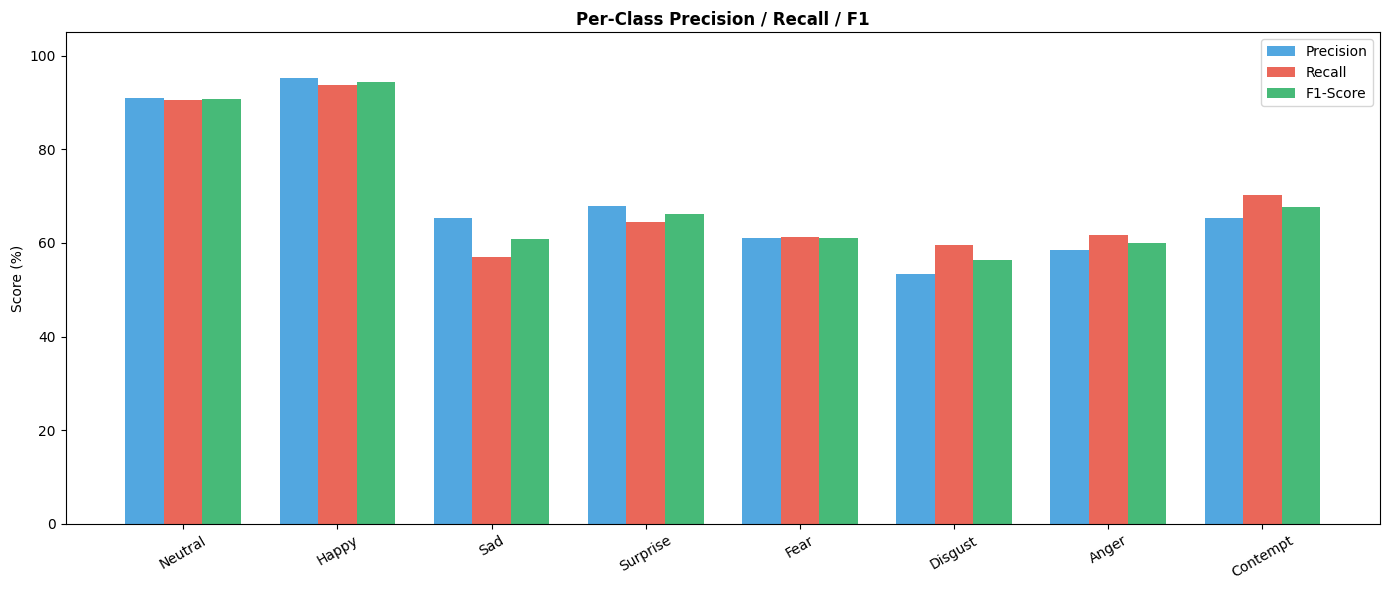

In [40]:
# ============================================================
# CELL 15: Confusion Matrix & Per-Class Analysis
# ============================================================
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(PLOT_DIR / '06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class metrics bar chart
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1s, sup = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(NUM_CLASSES)
w = 0.25
ax.bar(x - w, prec * 100, w, label='Precision', color='#3498DB', alpha=0.85)
ax.bar(x, rec * 100, w, label='Recall', color='#E74C3C', alpha=0.85)
ax.bar(x + w, f1s * 100, w, label='F1-Score', color='#27AE60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylabel('Score (%)')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(PLOT_DIR / '07_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

Extracting embeddings:   0%|          | 0/182 [00:00<?, ?it/s]

Running t-SNE...


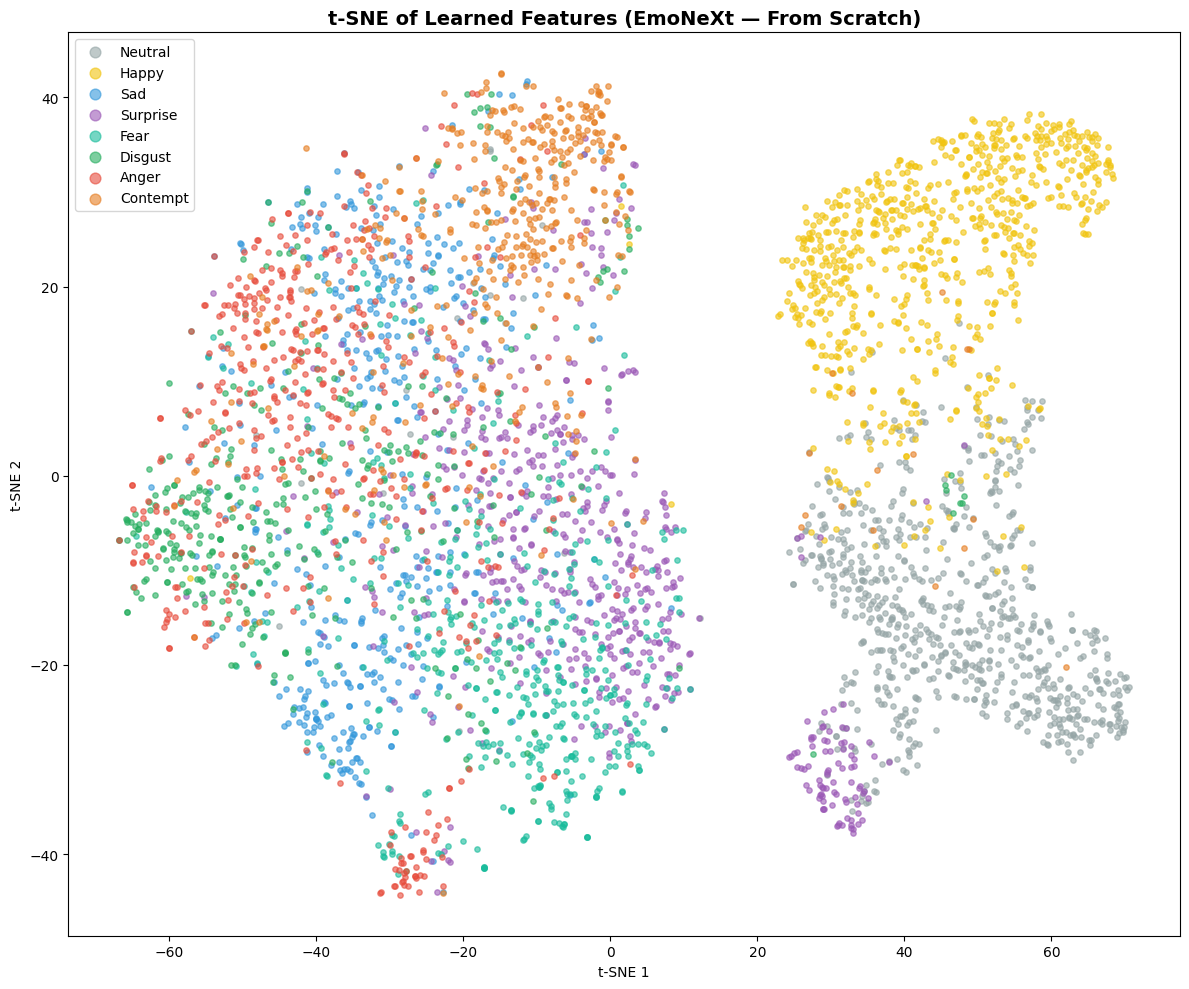

✅ Embeddings saved ((4357, 256))


In [41]:
# ============================================================
# CELL 16: t-SNE Feature Visualization
# ============================================================
from sklearn.manifold import TSNE

# Extract embeddings from test set
model.eval()
all_embeds = []
all_labels_emb = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Extracting embeddings'):
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        all_embeds.append(out['embeddings'].cpu().numpy())
        all_labels_emb.append(labels.numpy())

all_embeds = np.concatenate(all_embeds)
all_labels_emb = np.concatenate(all_labels_emb)

# t-SNE
print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
embeds_2d = tsne.fit_transform(all_embeds)

# Plot
colors_tsne = ['#95A5A6', '#F1C40F', '#3498DB', '#9B59B6',
               '#1ABC9C', '#27AE60', '#E74C3C', '#E67E22']

fig, ax = plt.subplots(figsize=(12, 10))
for i, cls in enumerate(CLASS_NAMES):
    mask = all_labels_emb == i
    ax.scatter(embeds_2d[mask, 0], embeds_2d[mask, 1],
               c=colors_tsne[i], label=cls, s=15, alpha=0.6)
ax.legend(fontsize=10, markerscale=2)
ax.set_title('t-SNE of Learned Features (EmoNeXt — From Scratch)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(PLOT_DIR / '08_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

# Save embeddings
np.save(EMBED_DIR / 'test_embeddings.npy', all_embeds)
np.save(EMBED_DIR / 'test_labels.npy', all_labels_emb)
print(f'✅ Embeddings saved ({all_embeds.shape})')

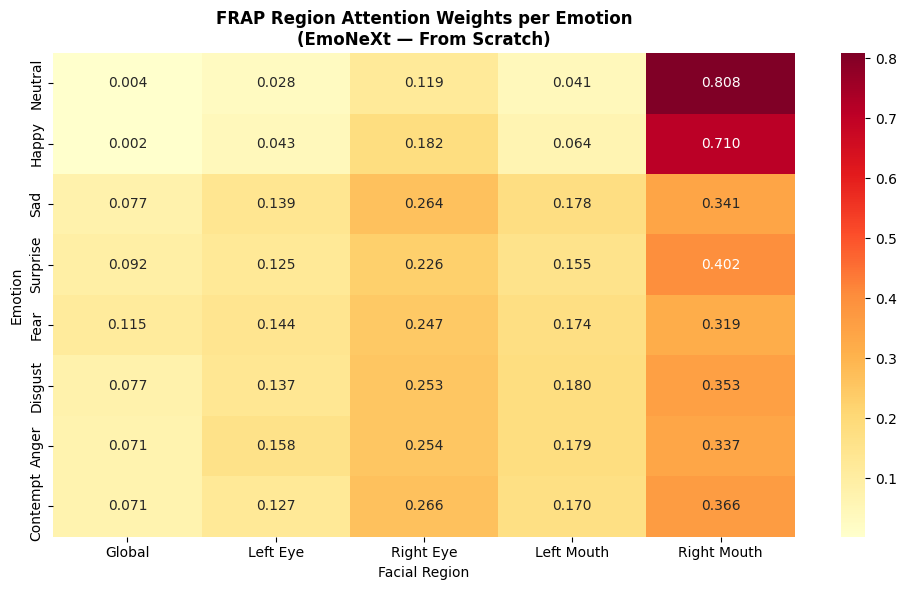

✅ Region gate analysis complete


In [42]:
# ============================================================
# CELL 17: FRAP Region Gate Analysis
# ============================================================
# Analyze which facial regions the model attends to per emotion

model.eval()
region_gates_by_class = defaultdict(list)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        out = model(imgs)
        gates = out['region_gates'].cpu().numpy()  # B×5
        for g, l in zip(gates, labels.numpy()):
            region_gates_by_class[int(l)].append(g)

# Average gates per class
region_names = ['Global', 'Left Eye', 'Right Eye', 'Left Mouth', 'Right Mouth']
gate_matrix = np.zeros((NUM_CLASSES, 5))
for cls_idx in range(NUM_CLASSES):
    if region_gates_by_class[cls_idx]:
        gate_matrix[cls_idx] = np.mean(region_gates_by_class[cls_idx], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(gate_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=region_names, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('FRAP Region Attention Weights per Emotion\n(EmoNeXt — From Scratch)',
             fontweight='bold')
ax.set_ylabel('Emotion'); ax.set_xlabel('Facial Region')
plt.tight_layout()
plt.savefig(PLOT_DIR / '09_region_gates.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Region gate analysis complete')

---
## 💾 Model Export

In [43]:
# ============================================================
# CELL 18: Model Export & Summary
# ============================================================

# Save final model
torch.save({
    'model_state': best_model_state,
    'class_names': CLASS_NAMES,
    'cfg': CFG,
    'val_acc': best_val_acc,
    'val_f1': best_val_f1,
    'total_params': sum(p.numel() for p in model.parameters()),
    'architecture': 'EmoNeXt',
    'trained_from_scratch': True,
    'focal_gammas': criterion.focal.get_gammas().tolist(),
}, MODEL_DIR / 'emonext_final.pth')

print('=' * 60)
print('💾 MODEL EXPORTED')
print('=' * 60)
print(f'  Architecture   : EmoNeXt (100% from scratch)')
print(f'  Parameters     : {sum(p.numel() for p in model.parameters())/1e6:.2f}M')
print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Test F1-Macro  : {test_f1*100:.2f}%')
print(f'  Saved to       : {MODEL_DIR / "emonext_final.pth"}')
print(f'  Pretrained     : ❌ None — 100% from scratch')
print('=' * 60)

💾 MODEL EXPORTED
  Architecture   : EmoNeXt (100% from scratch)
  Parameters     : 10.41M
  Test Accuracy  : 72.85%
  Test F1-Macro  : 69.66%
  Saved to       : emonext_outputs/saved_models/emonext_final.pth
  Pretrained     : ❌ None — 100% from scratch


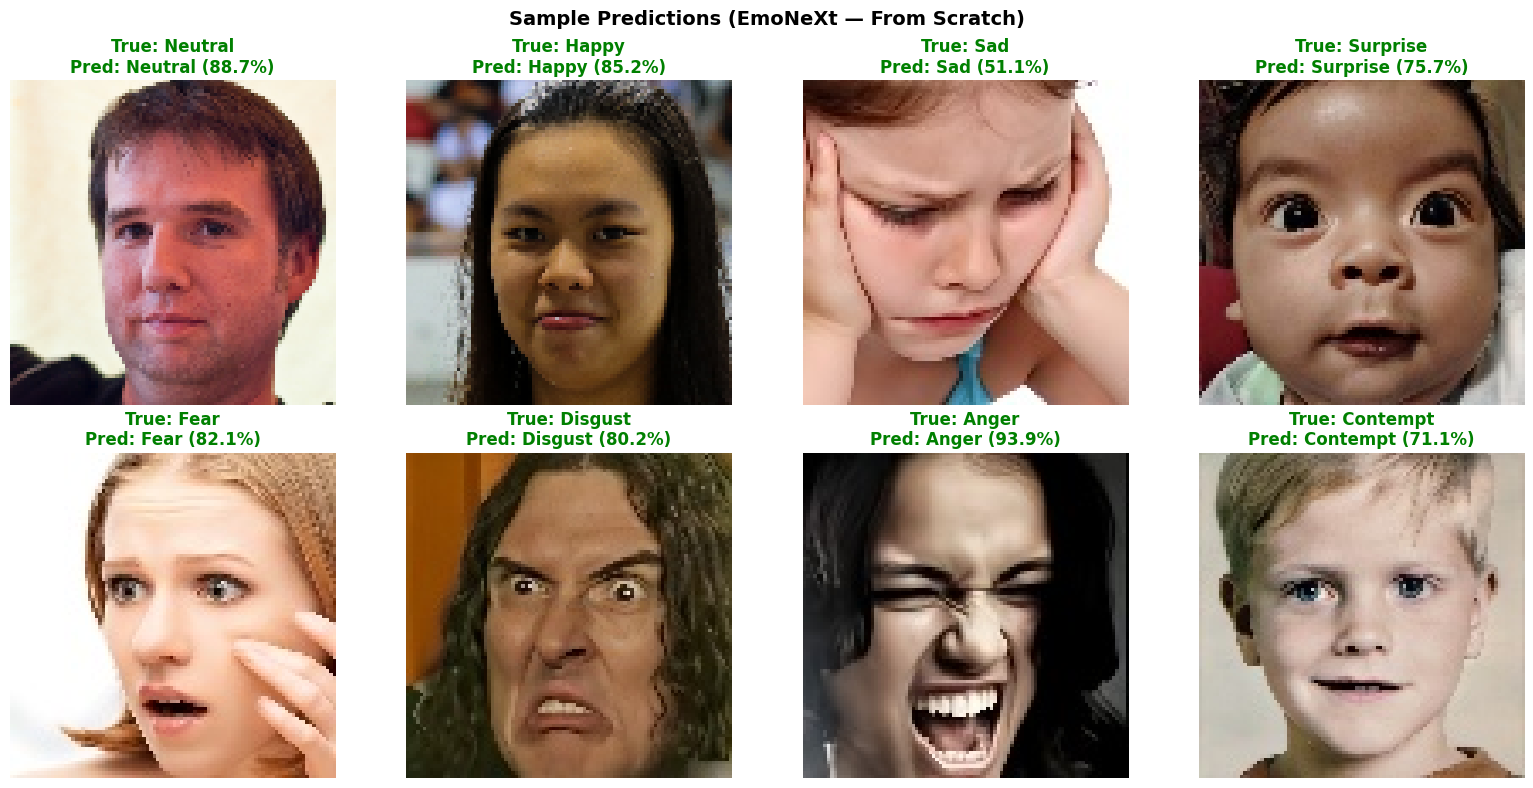

✅ Inference function ready


In [44]:
# ============================================================
# CELL 19: Single Image Inference
# ============================================================

def predict_image(image_path, model, device, transform):
    """Predict emotion from a single image."""
    img = cv2.imread(str(image_path))
    if img is None:
        img = np.array(Image.open(image_path).convert('RGB'))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tensor = transform(image=img)['image'].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(tensor)
        probs = F.softmax(out['logits'], dim=1).cpu().numpy()[0]

    pred_idx = probs.argmax()
    results = {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}

    return CLASS_NAMES[pred_idx], probs[pred_idx], results

# Demo inference
sample_paths = test_df.groupby('class_idx').first()['path'].values
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, path in enumerate(sample_paths[:8]):
    pred_cls, conf, all_probs = predict_image(path, model, DEVICE, VAL_AUG)
    true_cls = CLASS_NAMES[test_df[test_df['path'] == path]['class_idx'].values[0]]

    img = Image.open(path).convert('RGB')
    r, c = i // 4, i % 4
    axes[r, c].imshow(img)
    color = 'green' if pred_cls == true_cls else 'red'
    axes[r, c].set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1%})',
                         color=color, fontweight='bold')
    axes[r, c].axis('off')

plt.suptitle('Sample Predictions (EmoNeXt — From Scratch)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '10_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Inference function ready')

---
## 📝 Research Summary

### EmoNeXt — From-Scratch Facial Expression Recognition

**Key Contributions:**
1. **EmoNeXt Block** — Efficient inverted residual with depthwise-separable convolutions + SE attention, designed for from-scratch FER
2. **Multi-Frequency Spatial Attention (MFSA)** — Novel multi-scale dilated attention that captures expression information at different spatial frequencies
3. **Facial Region-Aware Pooling (FRAP)** — Novel pooling strategy with learnable region gates that attend to expression-relevant facial areas
4. **Adaptive Focal Loss** — Per-class learnable focusing parameter for automatic hard example mining
5. **Complete from-scratch training** — No pretrained weights, demonstrating that purpose-built architectures can learn facial expression features from raw pixels

**Training Details:**
- 100% from scratch (Kaiming He initialization)
- AdamW optimizer with warmup-cosine schedule
- Strong data augmentation (rotation, color, noise, cutout)
- Mixup + CutMix regularization
- Mixed precision training (AMP)
- Weighted sampling for class imbalance